In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, ClimateologyModel, SpatialGNNModel, GATv2Model


disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lags            = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = False,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest
    )    

dataorchestrator    = (DataOrchestrator(config).build())

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
global_hparams = {
    "lr"                : 0.00005,
    "n_epochs"          : 100,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.75, 'patience': 6, 'min_lr': 1e-8},
    'min_delta'         : 0,
    'loss'              : 'outbreakweighted',
    'loss_kwargs'       : {'outbreak_threshold': 0 , 'outbreak_weight': 5},
    'patience'          : 20,
    }


shallowdata         = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('boolean_neighbors_self').construct_dataloaders()
graphdataloader_gr1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity1').construct_dataloaders()
graphdataloader_cm1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter1').construct_dataloaders()
graphdataloader_gr2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity4').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter4').construct_dataloaders()

In [3]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')

/home/de-schrijvers/projects/germany_gnn/srcv2/models/baselines/climateology.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week


ClimateologyModel(name='Climateology Model')


==             GATv2 identity_graph             ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


Training epochs:  55%|███████████████████████████████████████                                | 55/100 [04:01<03:17,  4.40s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.7616


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 114.93it/s]


Test loss: 1.1352

==           GATv2 boolean neighbors            ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))


...

Training epochs:  49%|██████████████████████████████████▊                                    | 49/100 [04:30<04:41,  5.52s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.8312


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 250.68it/s]

Test loss: 1.1709


GATv2Model(name='GATv2 commuter 3')

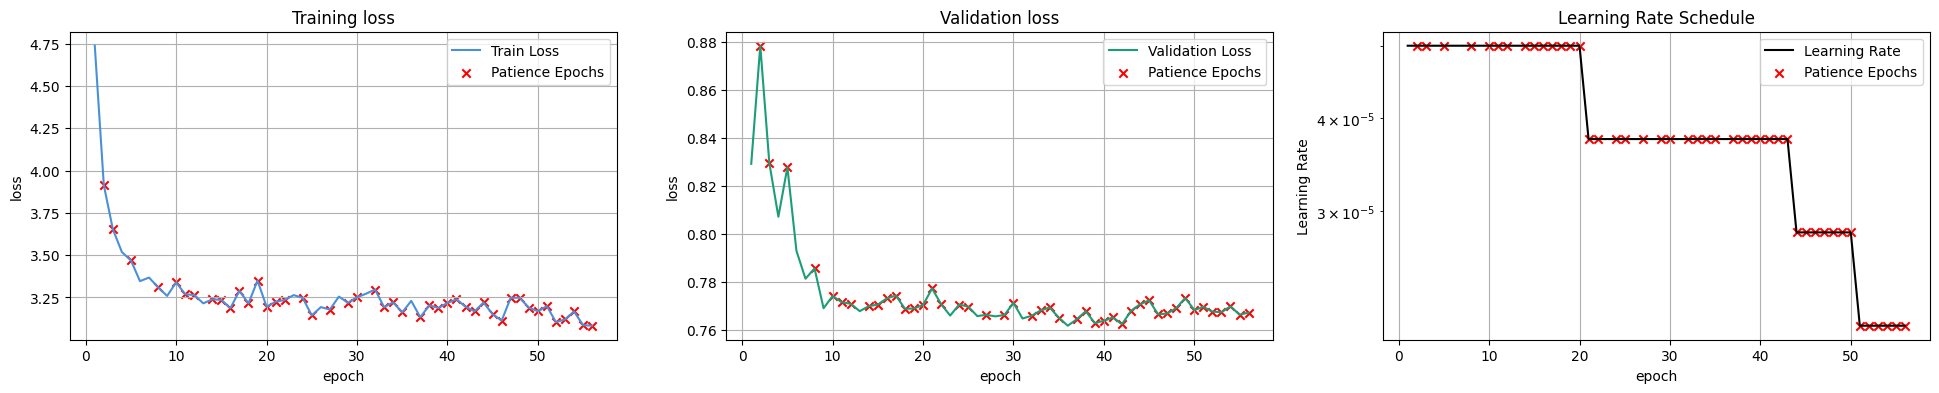

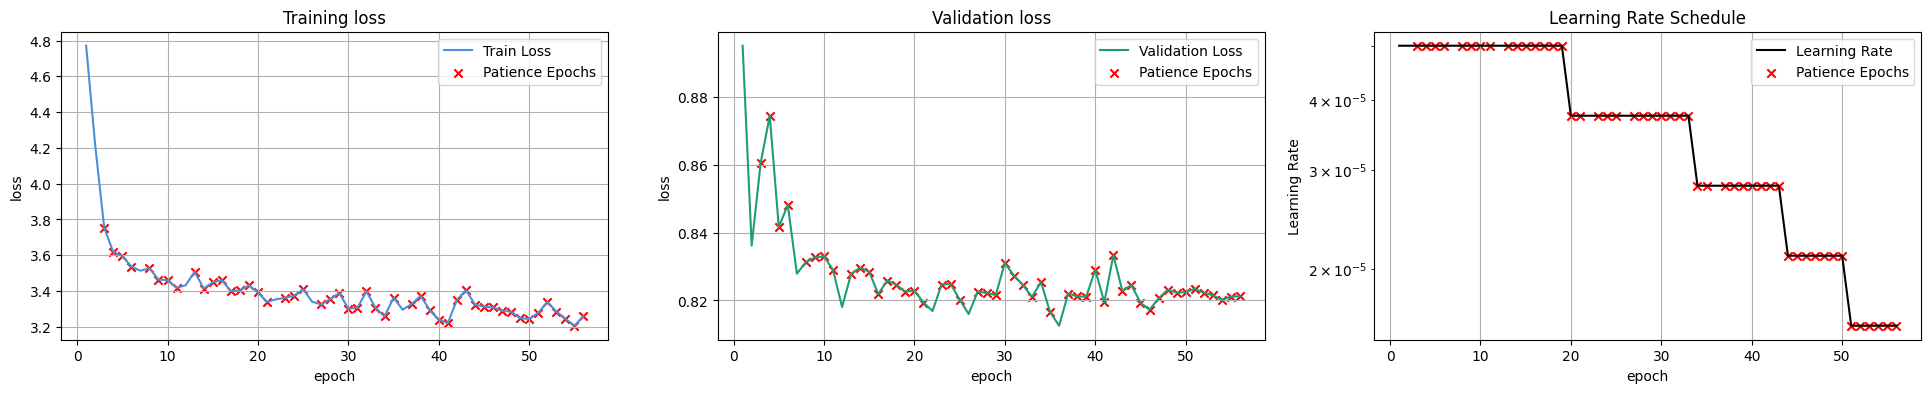

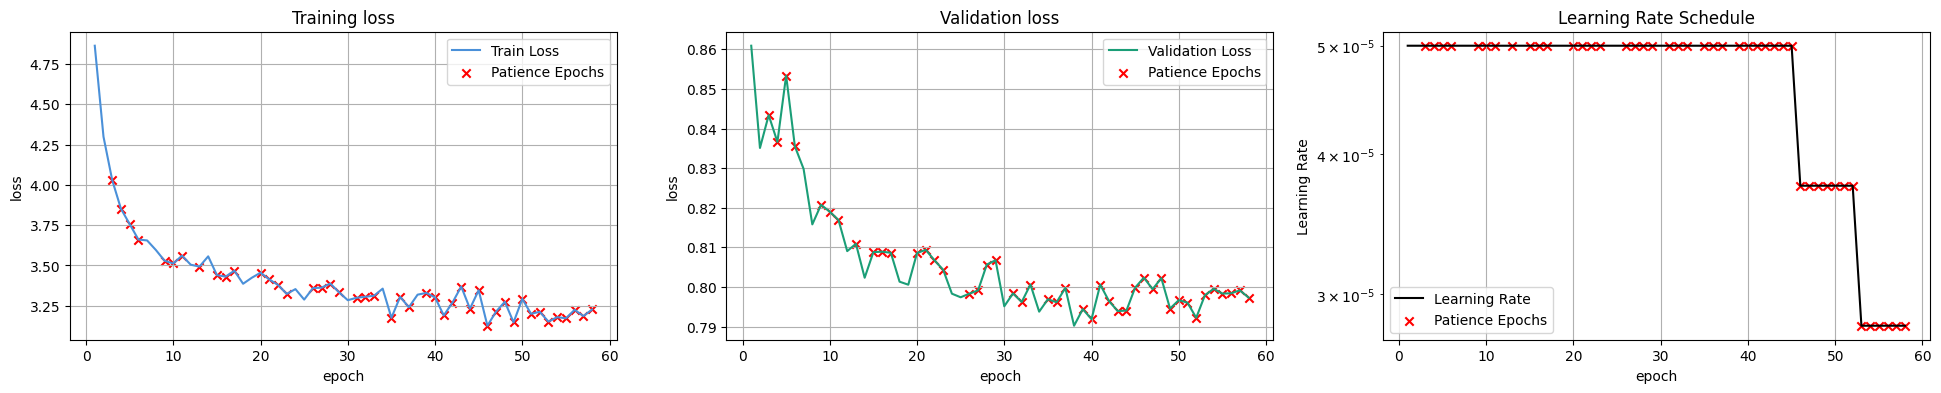

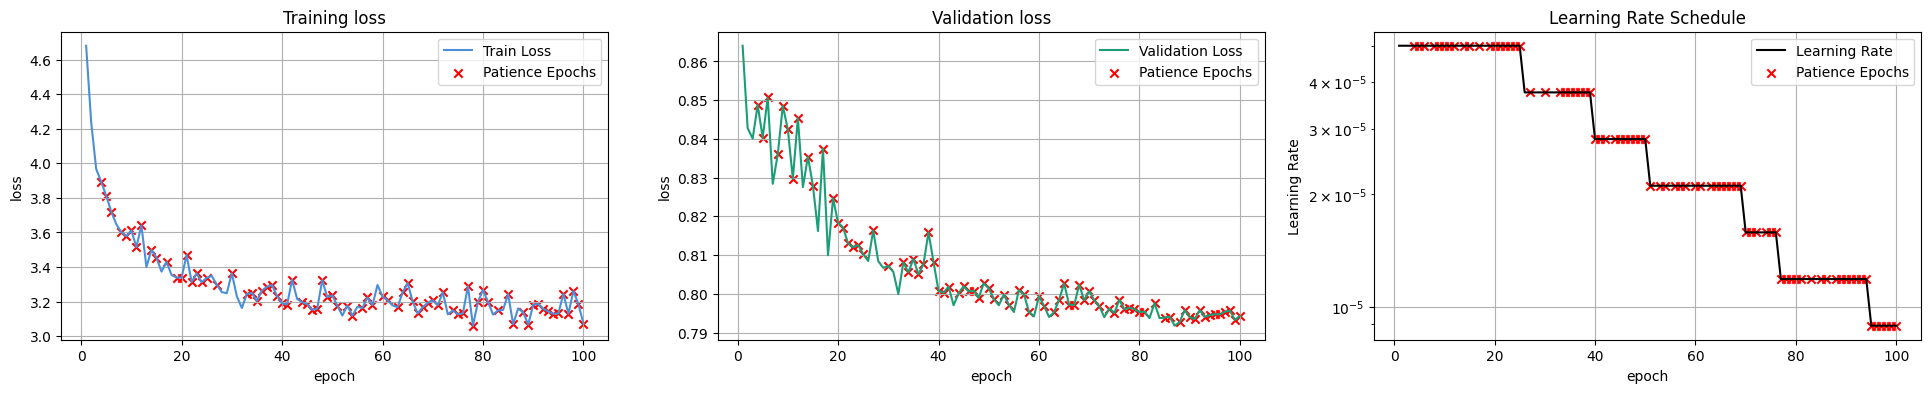

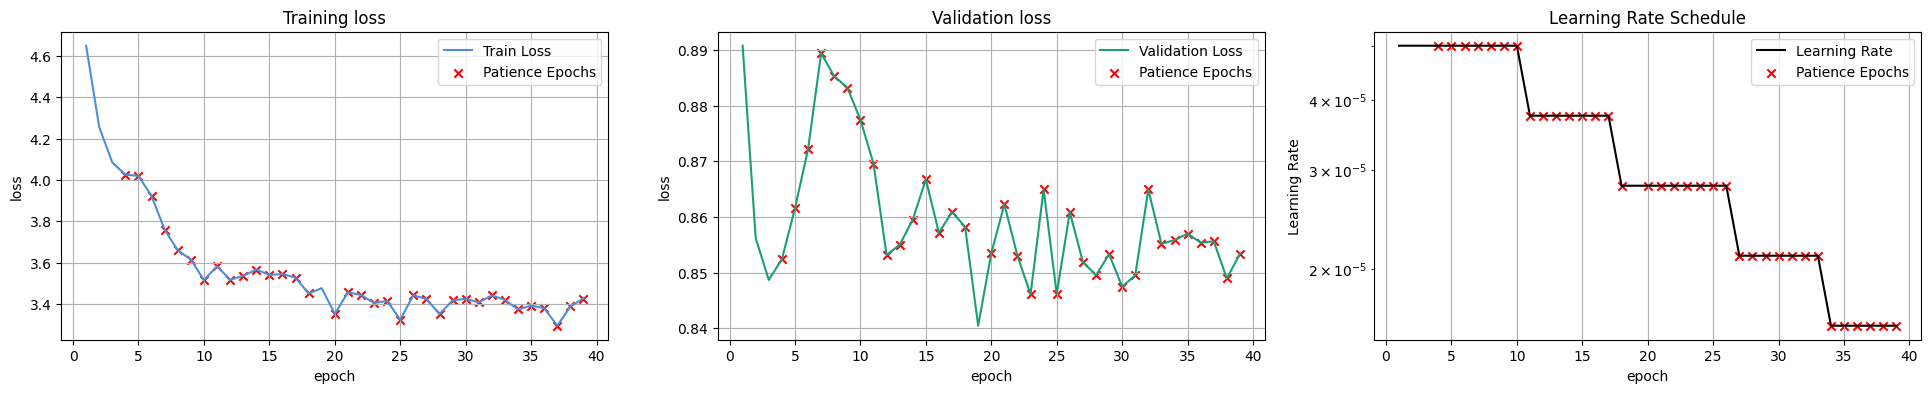

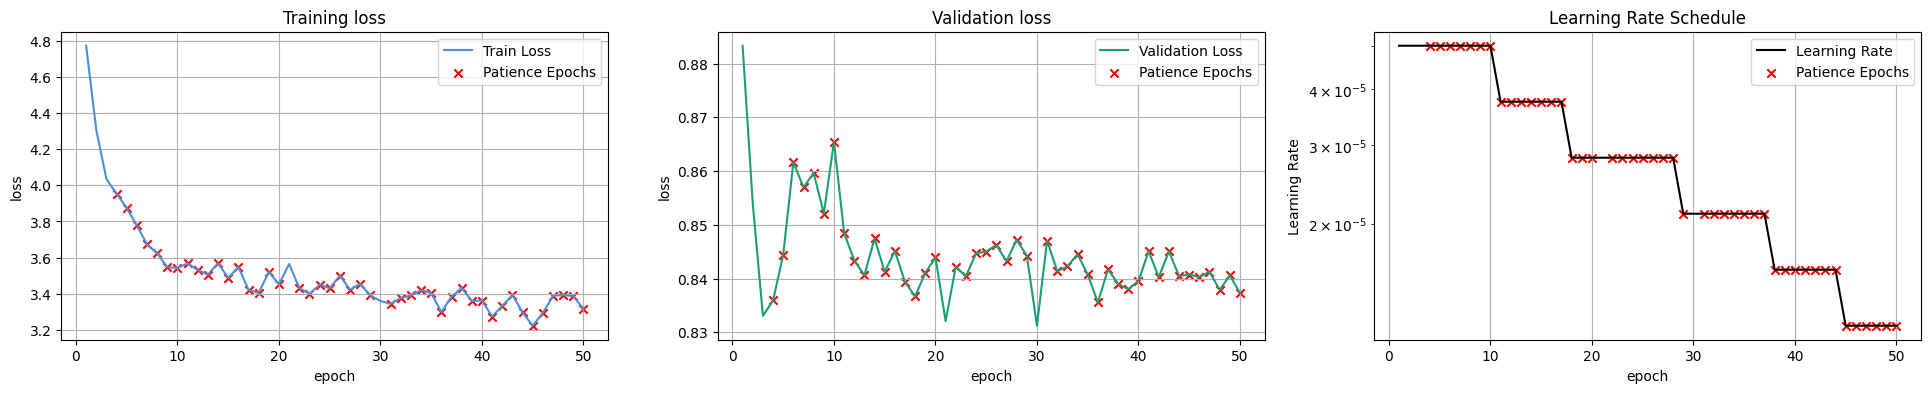

In [ ]:
spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'GATv2 identity_graph')
spatiotemporal_model1.set_model_hparams()
spatiotemporal_model1.set_global_hparams(**global_hparams)
spatiotemporal_model1.train(verbose = 0)
spatiotemporal_model1.forecast('test')

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'GATv2 boolean neighbors')
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train(verbose = 0)
spatiotemporal_model2.forecast('test')

spatiotemporal_model3 = GATv2Model(graphdataloader_gr1, name = 'GATv2 gravity 1')
spatiotemporal_model3.set_model_hparams()
spatiotemporal_model3.set_global_hparams(**global_hparams)
spatiotemporal_model3.train(verbose = 0)
spatiotemporal_model3.forecast('test')

spatiotemporal_model4 = GATv2Model(graphdataloader_cm1, name = 'GATv2 commuter 1')
spatiotemporal_model4.set_model_hparams()
spatiotemporal_model4.set_global_hparams(**global_hparams)
spatiotemporal_model4.train(verbose = 0)
spatiotemporal_model4.forecast('test')

spatiotemporal_model5 = GATv2Model(graphdataloader_gr2, name = 'GATv2 gravity 2')
spatiotemporal_model5.set_model_hparams()
spatiotemporal_model5.set_global_hparams(**global_hparams)
spatiotemporal_model5.train(verbose = 0)
spatiotemporal_model5.forecast('test')

spatiotemporal_model6 = GATv2Model(graphdataloader_cm2, name = 'GATv2 commuter 3')
spatiotemporal_model6.set_model_hparams()
spatiotemporal_model6.set_global_hparams(**global_hparams)
spatiotemporal_model6.train(verbose = 0)
spatiotemporal_model6.forecast('test')


==              GCN identity_graph              ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


Training epochs:   0%|                                                                                | 0/100 [00:00<?, ?it/s]

Training epochs:  37%|██████████████████████████▎                                            | 37/100 [02:13<03:47,  3.60s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.8287


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 243.27it/s]


...

Training epochs:  43%|██████████████████████████████▌                                        | 43/100 [02:41<03:34,  3.76s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.8334


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 238.79it/s]

Test loss: 1.2824


SpatialGNNModel(name='GCN commuter 3')

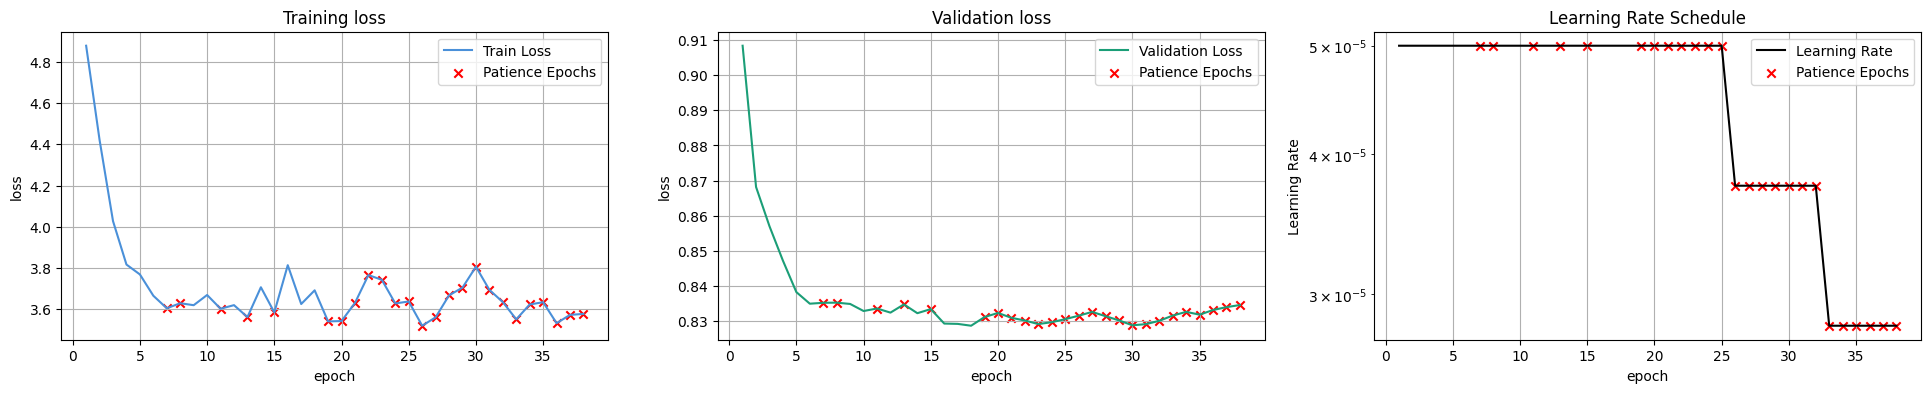

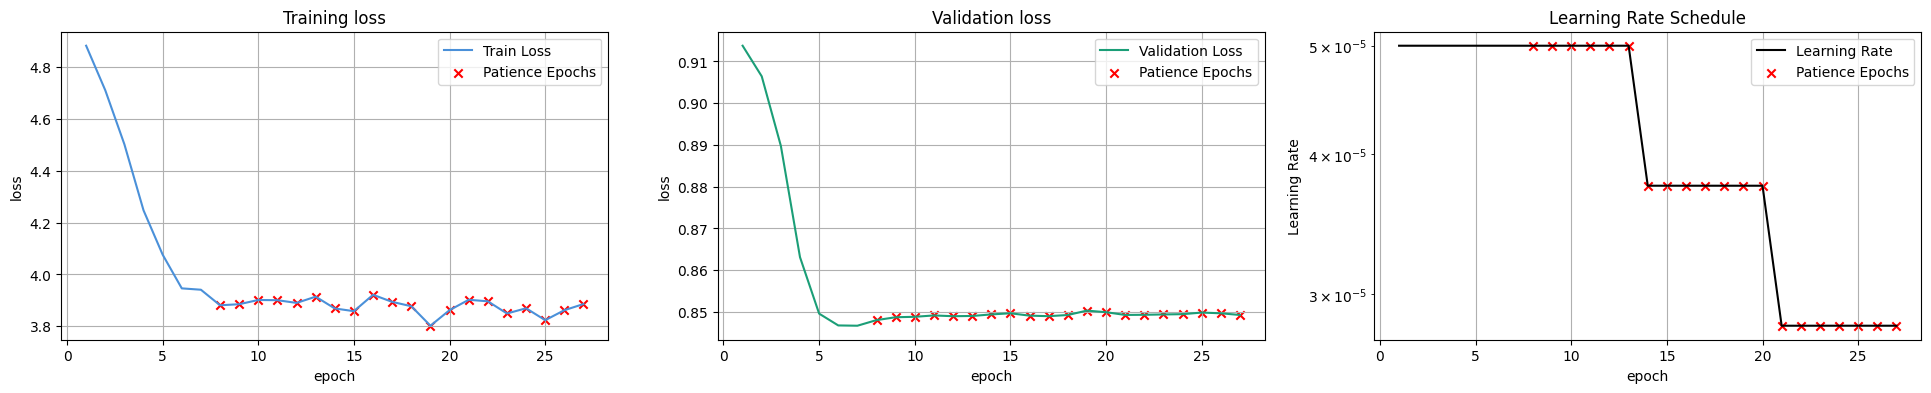

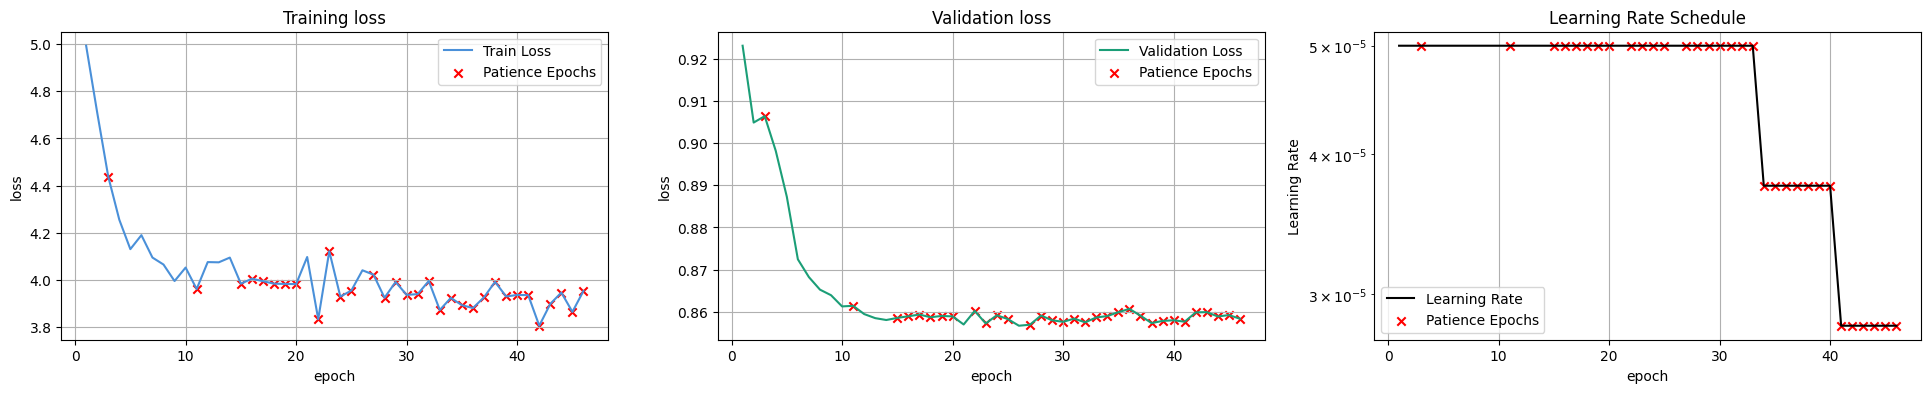

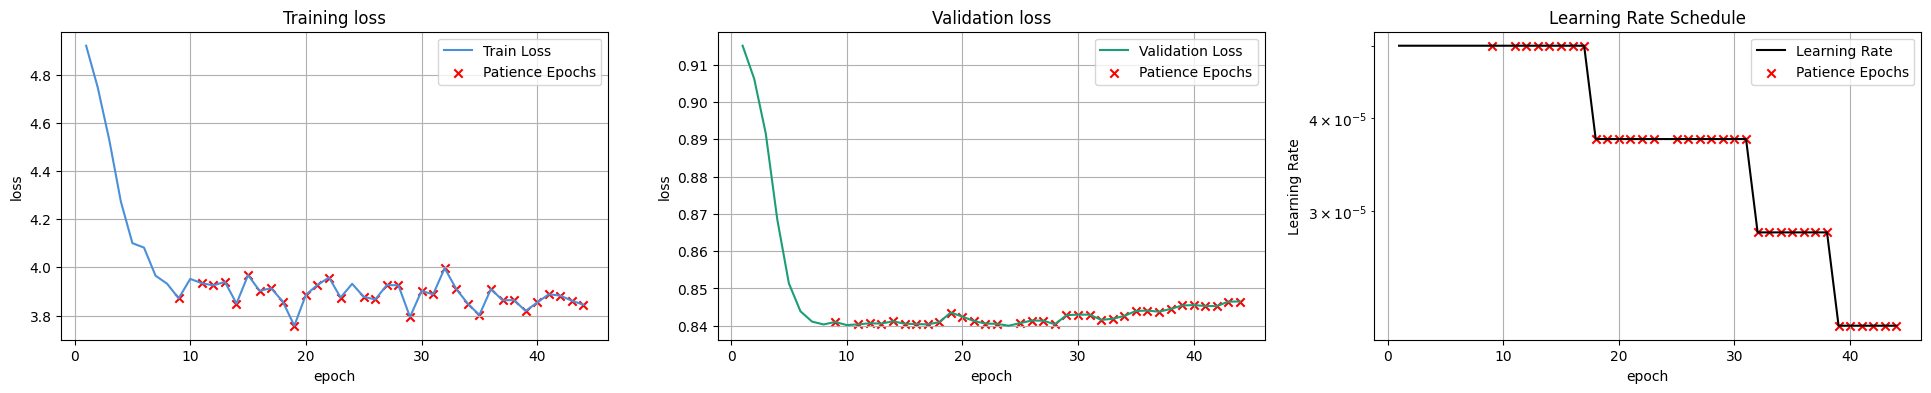

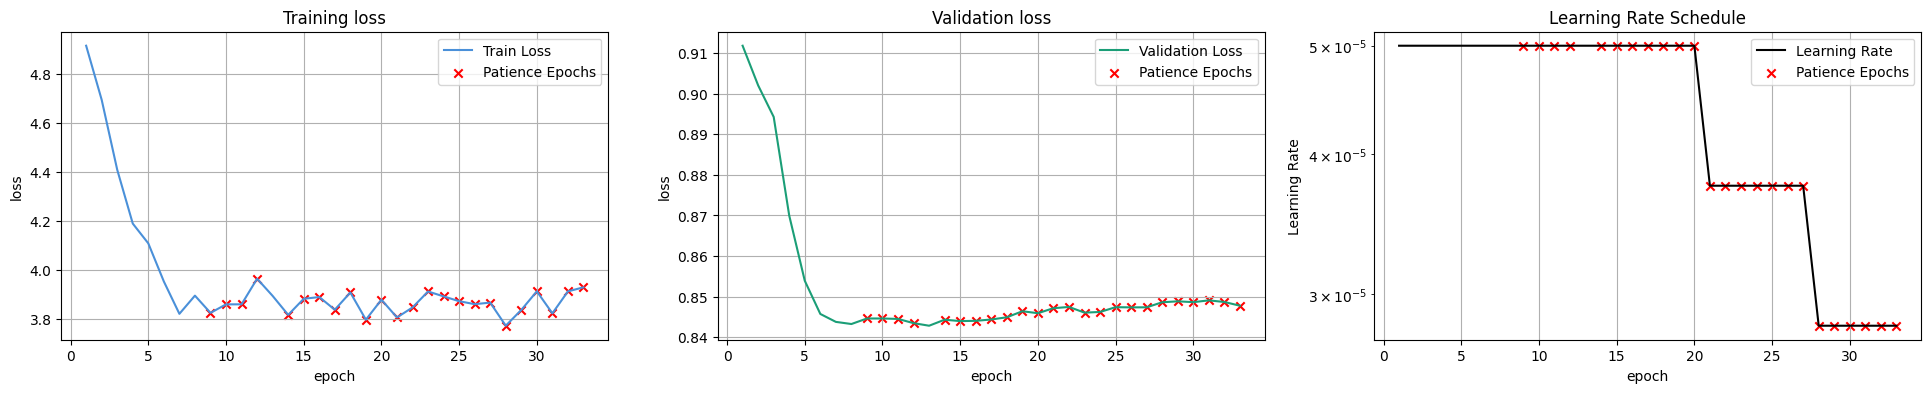

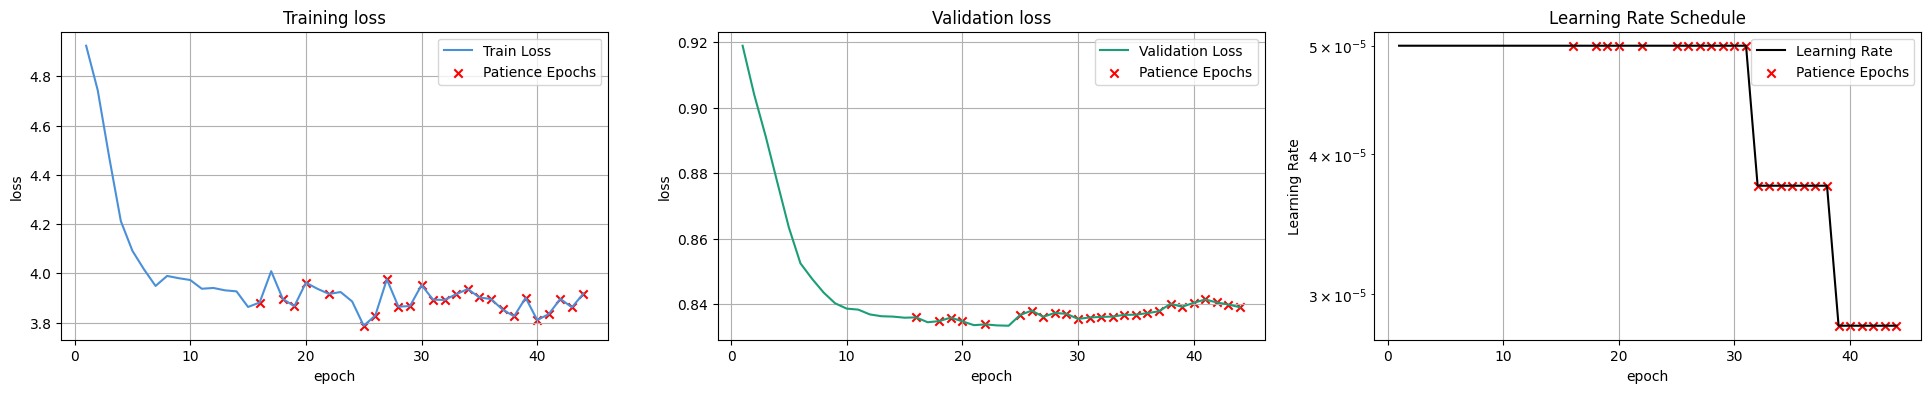

In [5]:
from srcv2.models.deep.spatialgnnmodel import SpatialGNNModel
spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'GCN identity_graph')
spatial_model1.set_model_hparams()
spatial_model1.set_global_hparams(**global_hparams)
spatial_model1.train(verbose = 0)
spatial_model1.forecast('test')

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'GCN boolean neighbors')
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train(verbose = 0)
spatial_model2.forecast('test')

spatial_model3 = SpatialGNNModel(graphdataloader_gr1, name = 'GCN gravity 1')
spatial_model3.set_model_hparams()
spatial_model3.set_global_hparams(**global_hparams)
spatial_model3.train(verbose = 0)
spatial_model3.forecast('test')

spatial_model4 = SpatialGNNModel(graphdataloader_cm1, name = 'GCN commuter 1')
spatial_model4.set_model_hparams()
spatial_model4.set_global_hparams(**global_hparams)
spatial_model4.train(verbose = 0)
spatial_model4.forecast('test')

spatial_model5 = SpatialGNNModel(graphdataloader_gr2, name = 'GCN gravity 2')
spatial_model5.set_model_hparams()
spatial_model5.set_global_hparams(**global_hparams)
spatial_model5.train(verbose = 0)
spatial_model5.forecast('test')

spatial_model6 = SpatialGNNModel(graphdataloader_cm2, name = 'GCN commuter 3')
spatial_model6.set_model_hparams()
spatial_model6.set_global_hparams(**global_hparams)
spatial_model6.train(verbose = 0)
spatial_model6.forecast('test')

In [6]:
from srcv2.evaluation import Evaluator

In [7]:
eval1 = Evaluator([spatial_model1, spatiotemporal_model1])
eval2 = Evaluator([spatial_model2, spatiotemporal_model2])
eval3 = Evaluator([spatial_model3, spatiotemporal_model3])
eval4 = Evaluator([spatial_model4, spatiotemporal_model4])
eval5 = Evaluator([spatial_model5, spatiotemporal_model5])
eval6 = Evaluator([spatial_model6, spatiotemporal_model6])
evals = [eval1, eval2, eval3, eval4, eval5, eval6]
for e in evals:
    e.add_evaluation(0, 'test')

computing metrics:   0%|                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.11it/s]


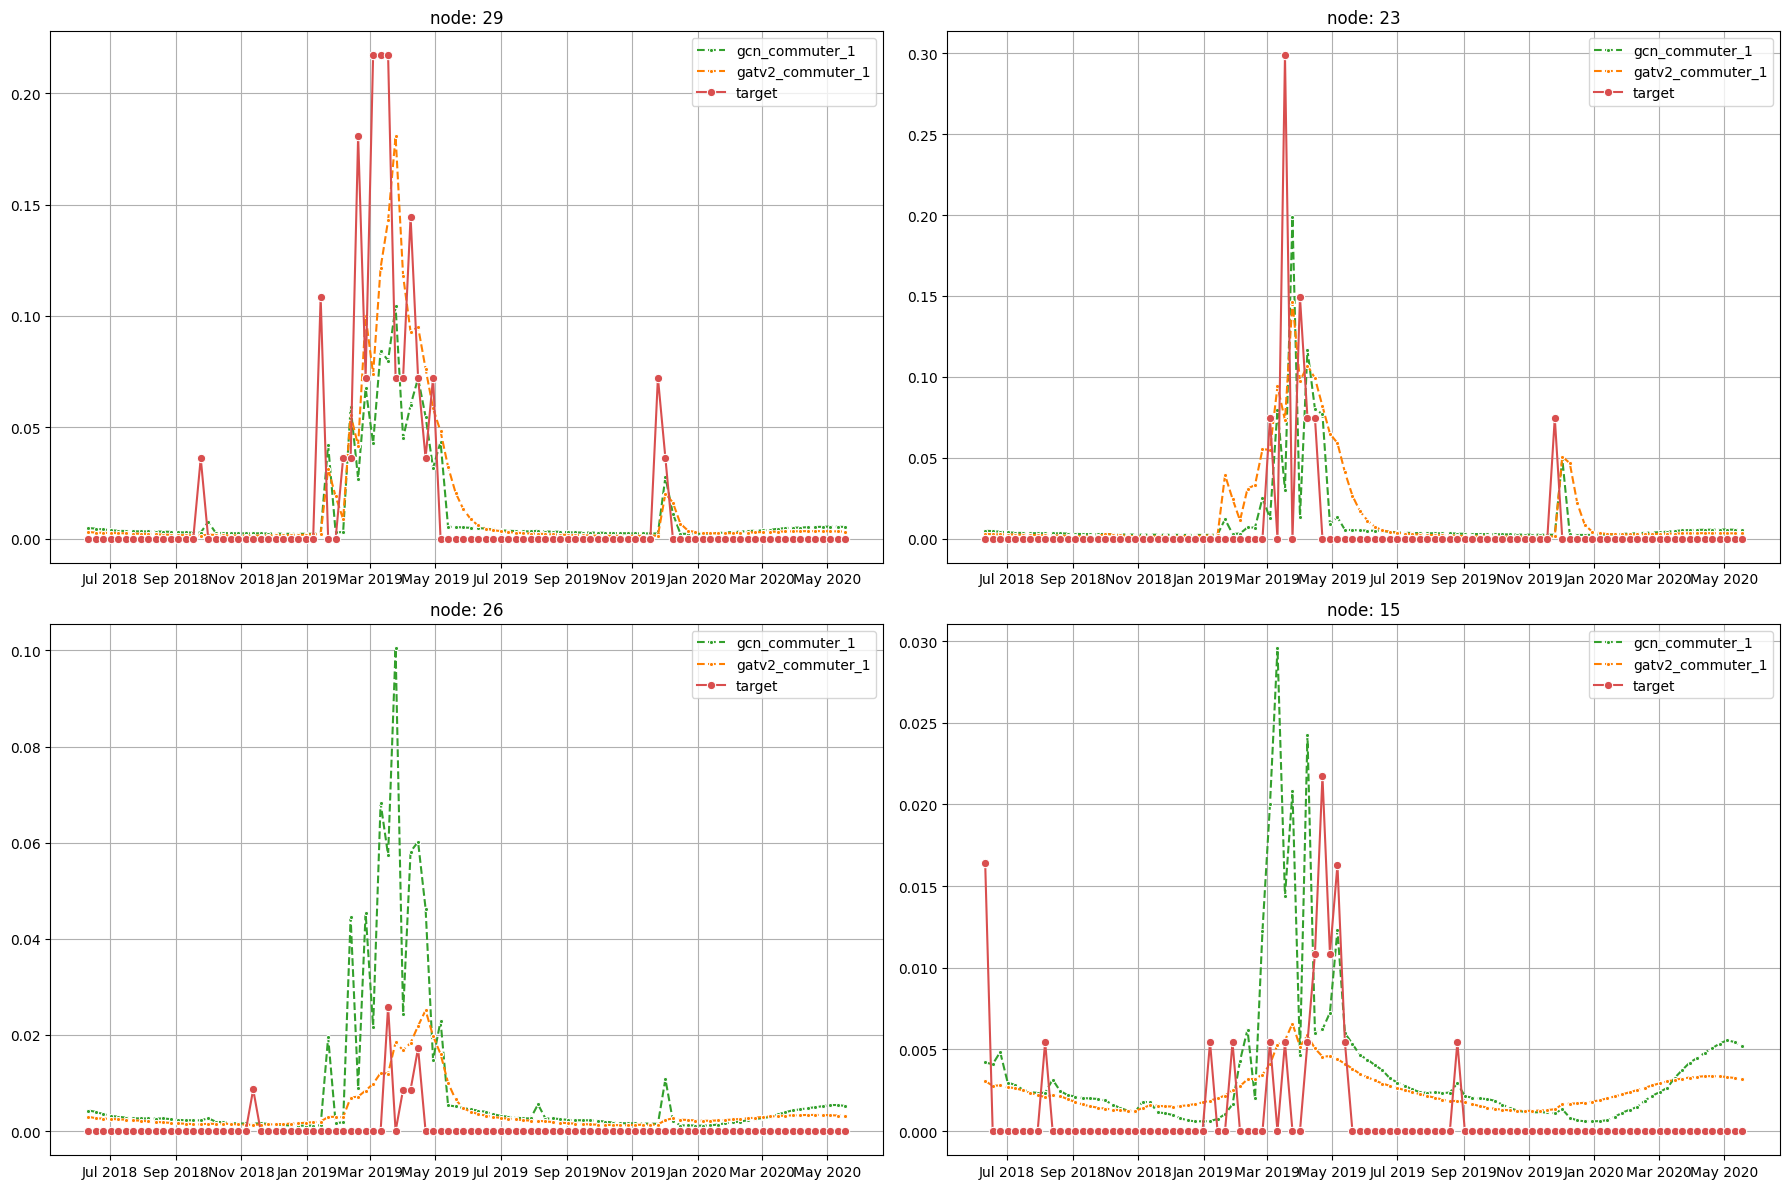

In [14]:
eval4.plotter.plot_timeseries(nodes = ['29','23','26','15'])

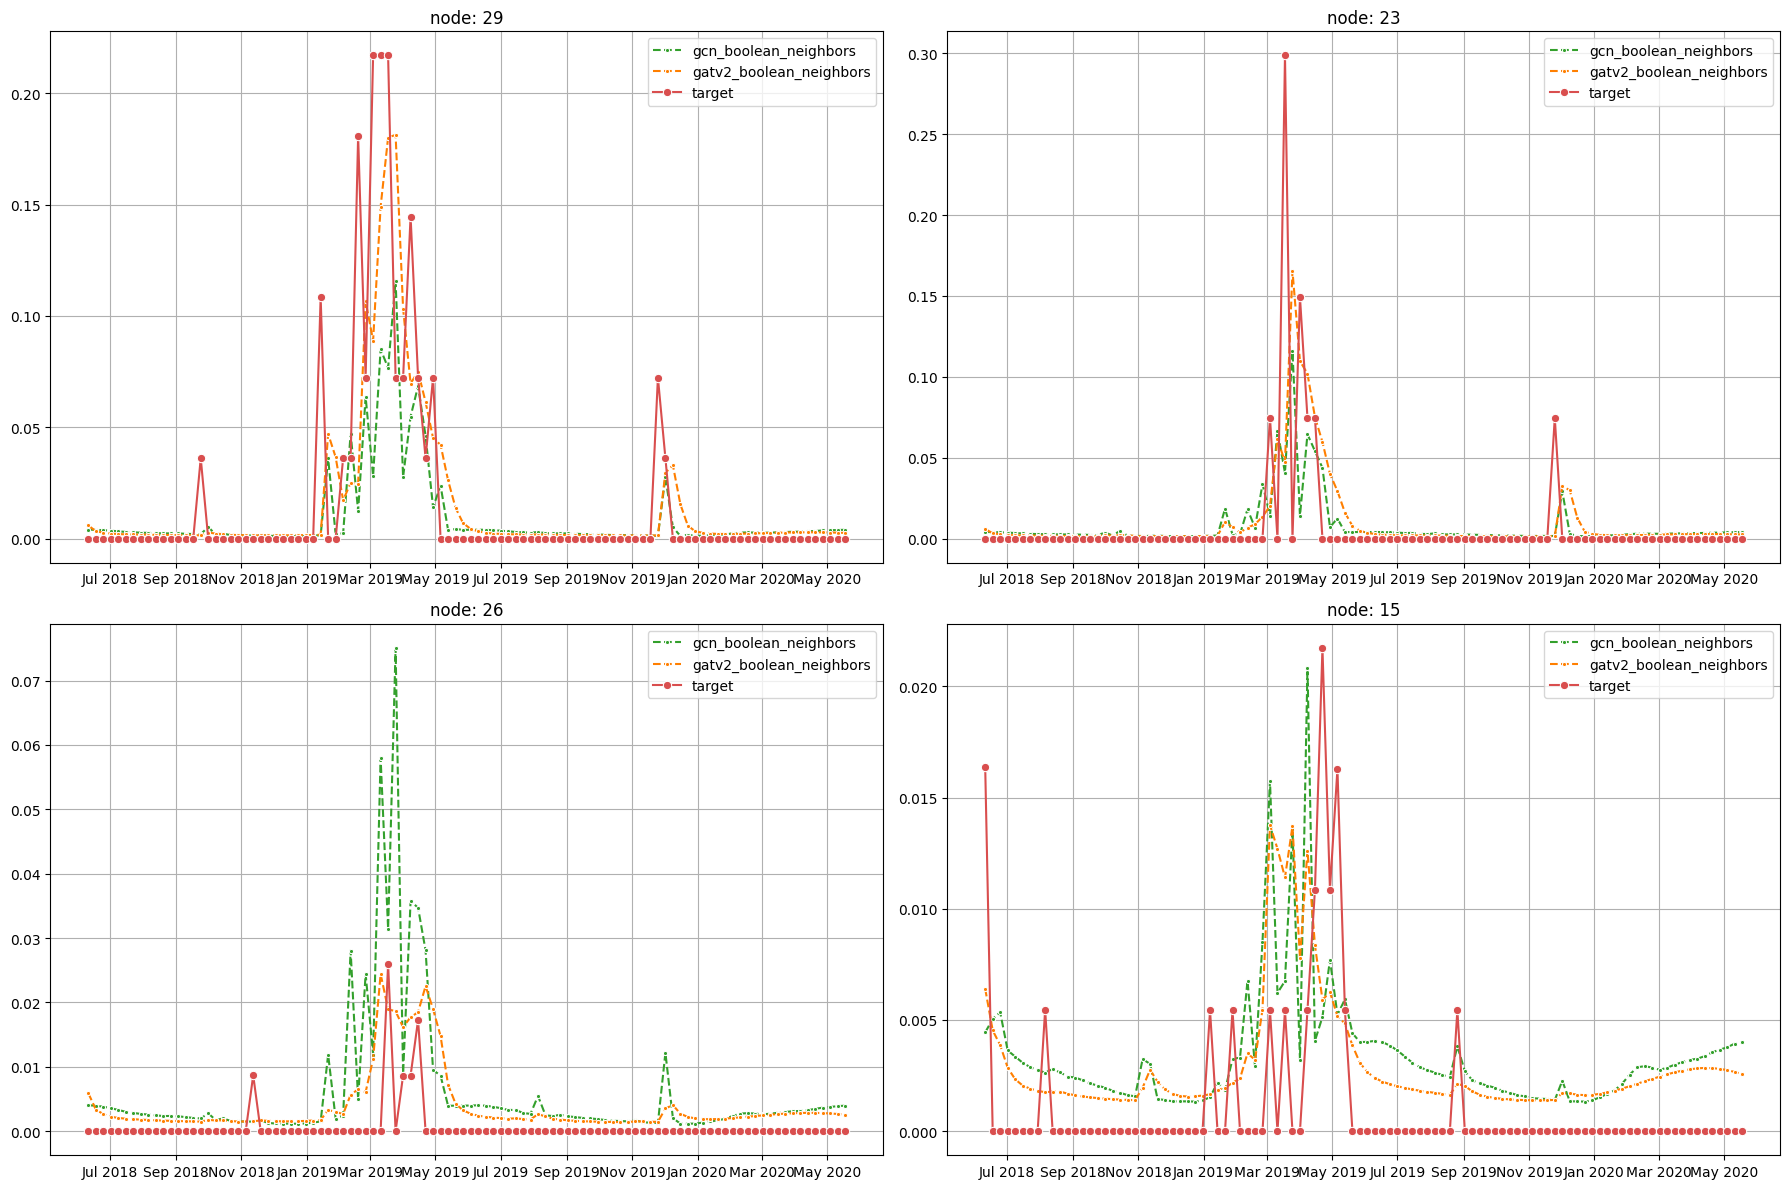

In [8]:
eval2.plotter.plot_timeseries(nodes = ['29','23','26','15'])